# 05 — Surrogate-Assisted Optimization

Run the full optimization loop:
1. Load trained surrogate
2. Configure mission + constraints (aero + propulsion)
3. Surrogate-assisted Differential Evolution
4. Track convergence (L/D, endurance, T/D)
5. Top-10 feasible designs with propulsion balance

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.aero.mission import MissionCondition, FeasibilityConfig
from src.surrogate.model import SurrogateModel
from src.optimization.problem import run_surrogate_assisted, run_differential_evolution
from src.optimization.database import EvaluationDatabase
from src.parameterization.design_variables import params_from_vector

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [ ]:
%load_ext autoreload
%autoreload 2

## 1. Configuration

In [2]:
mission = MissionCondition()
feasibility = FeasibilityConfig()

print(f'Mission: V={mission.velocity} m/s, MTOW={mission.mtow} kg')
print(f'Mass budget: {mission.mass_budget:.3f} kg')
print(f'T_available @ cruise: {mission.thrust_available:.2f} N')

Mission: V=20.0 m/s, MTOW=1.5 kg
Mass budget: 1.190 kg
T_available @ cruise: 4.29 N


## 2. Run Surrogate-Assisted Optimization

In [7]:
result = run_surrogate_assisted(
    mission=mission,
    feasibility=feasibility,
    surrogate_path='../models/surrogate_v2',
    n_restarts=3,
    n_infill=40,
    max_cycles=5,
    surrogate_de_maxiter=200,
    surrogate_de_popsize=50,
    seed=42,
    verbose=True,
)

=== Surrogate-Assisted Optimization ===
Design variables: 30
Loaded pre-trained surrogate from ../models/surrogate_v2
  Architecture: MLP 256-128-64, 5 ensemble


--- Cycle 1/5 ---
  Running 3 DE restarts on surrogate (pop=50, iter=200)...
  Surrogate best: L/D=22.31, penalty=0.00
  Validating 40 candidates with AVL...
    infill  1/40  L/D= 22.97 (surr=22.31) [X]
    infill  2/40  L/D= 22.84 (surr=22.30) [X]
    infill  3/40  L/D= 22.87 (surr=22.28) [OK]
    infill  4/40  L/D= 22.23 (surr=22.22) [OK]
    infill  5/40  L/D= 22.80 (surr=22.19) [X]
    infill  6/40  L/D= 22.06 (surr=22.28) [OK]
    infill  7/40  L/D= 22.15 (surr=22.26) [OK]
    infill  8/40  L/D= 22.95 (surr=22.54) [X]
    infill  9/40  L/D= 22.74 (surr=22.13) [OK]
    infill 10/40  L/D= 22.87 (surr=22.52) [X]
    infill 11/40  L/D= 22.75 (surr=22.22) [OK]
    infill 12/40  L/D= 22.18 (surr=22.38) [OK]
    infill 13/40  L/D= 22.77 (surr=22.12) [X]
    infill 14/40  L/D= 22.03 (surr=22.18) [OK]
    infill 15/40  L/D= 22.5

## 3. Best Design Summary

In [8]:
best = result['best_result']
best_params = result['best_params']

if best:
    print('═══ Best Feasible Design ═══')
    print(f'  L/D          = {best["L_over_D"]:.2f}')
    print(f'  CL           = {best["CL"]:.4f}')
    print(f'  CD           = {best["CD"]:.5f} (wing={best["CD0_wing"]:.5f} + body={best["CD0_body"]:.5f} + ind={best["CDi"]:.5f})')
    print(f'  CM           = {best["CM"]:.4f}')
    print(f'  Static margin= {best["static_margin"]:.3f}')
    print(f'  Cn_beta      = {best["Cn_beta"]:.4f}')
    print(f'  Span         = {2*best_params.half_span:.2f} m')
    print(f'  AR           = {best["AR"]:.1f}')
    print(f'  Struct mass  = {best["struct_mass"]:.3f} kg')
    print(f'  ─── Propulsion ───')
    print(f'  T/D          = {best["T_over_D"]:.2f}')
    print(f'  P_elec       = {best["P_elec"]:.1f} W')
    print(f'  Endurance    = {best["endurance_min"]:.1f} min')
    print(f'  Range        = {best["range_km"]:.1f} km')
    print(f'  Duct fits    = {best["duct_fits"]}')
    print(f'  Feasible     = {best["is_feasible"]}')
else:
    print('No feasible design found')

═══ Best Feasible Design ═══
  L/D          = 22.87
  CL           = 0.4142
  CD           = 0.01811 (wing=0.00424 + body=0.00541 + ind=0.00846)
  CM           = -0.1721
  Static margin= 0.090
  Cn_beta      = 0.4497
  Span         = 2.00 m
  AR           = 8.0
  Struct mass  = 0.825 kg
  ─── Propulsion ───
  T/D          = 1.57
  P_elec       = 116.9 W
  Endurance    = 8.0 min
  Range        = 9.6 km
  Duct fits    = True
  Feasible     = True


## 4. Convergence

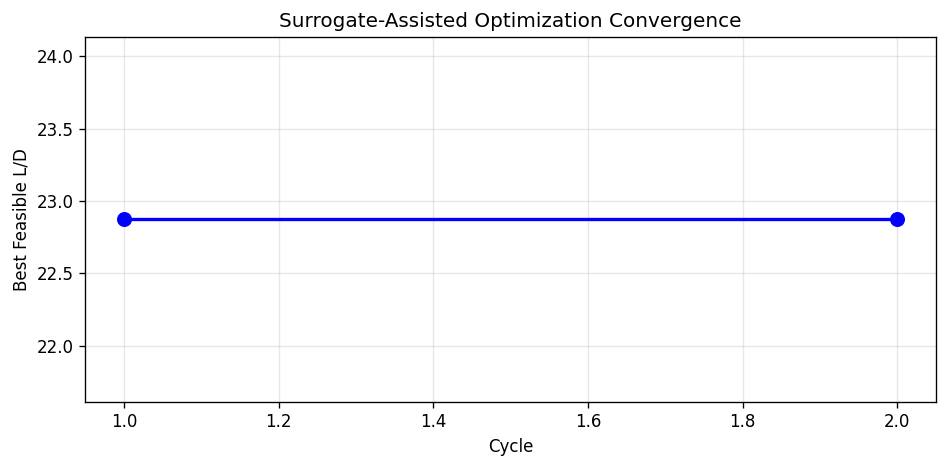

Total VLM evals: 80


In [9]:
if result.get('cycle_history'):
    cycles = result['cycle_history']
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot([c['cycle'] for c in cycles], [c['best_ld'] for c in cycles], 'bo-', lw=2, ms=8)
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Best Feasible L/D')
    ax.set_title('Surrogate-Assisted Optimization Convergence')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f'Total VLM evals: {result["total_vlm_evals"]}')

## 5. Save Results

In [10]:
import json
from pathlib import Path

out = Path('../output')
out.mkdir(exist_ok=True)

if result.get('best_x') is not None:
    np.save(out / 'best_x.npy', result['best_x'])
    
if result.get('database'):
    result['database'].save(out / 'eval_database.json')
    
print(f'Results saved to {out}')

Results saved to ..\output
